# Modelowanie nieliniowego obciążenia elektrycznego względem temperatury za pomocą PROC GAMPL

## Podsumowanie wykonawcze

Zapotrzebowanie na energię elektryczną zależy od temperatury w silnie nieliniowy sposób, w kształcie litery U (ogrzewanie w chłodzie, chłodzenie w upale), którego modele liniowe nie wychwytują. Ten notatnik buduje syntetyczną godzinową próbę obciążenia dla regionalnego zakładu energetycznego i dopasowuje spenalizowany uogólniony model addytywny za pomocą **PROC GAMPL**, wykorzystując splajny regresyjne do odtworzenia gładkich krzywych obciążenie-temperatura, obciążenie-godzina i obciążenie-wilgotność, przy jednoczesnym uwzględnieniu parametrycznego efektu dnia roboczego/weekendu.

Na próbie 100 obserwacji udostępnianej przez to licencjonowane środowisko GAMPL odtwarza wbudowaną przez nas strukturę. Wygładzenie temperatury `s(TEMP_C)` jest istotnie zakrzywione (efektywne DF 5,53, *p* < 0,0001); wygładzenie dobowe `s(HOUR)` jest najbardziej elastycznym członem (EDF 6,87, *p* < 0,0001); a wygładzenie wilgotności `s(HUMIDITY)` zapada się do pojedynczego, niemal liniowego stopnia swobody (EDF 1,00, *p* = 0,07) — kara wyprostowuje człon, którego dane ledwie wspierają. Parametryczny efekt `daytype` umieszcza weekendy około 44,5 MW poniżej dni roboczych, co odpowiada przesunięciu poziomu o 40 MW w procesie generującym dane. Cały model zużywa 15,4 efektywnych stopni swobody i osiąga wynik GCV 239,6 (AIC 831,0).

## Źródła danych

| Zbiór danych | Wiersze | Opis | Kluczowe zmienne |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Syntetyczne godzinowe obserwacje z systemu prognozowania obciążenia regionalnego zakładu energetycznego | `load_mw` (obciążenie systemu, MW), `temp_c` (temperatura otoczenia, st. C), `hour` (godzina doby, 0-23), `humidity` (wilgotność względna, %), `daytype` (klasa Weekday/Weekend), `is_summer` (flaga sezonu użyta przy generowaniu danych) |

Wszystkie dane są generowane wewnątrz notatnika za pomocą `call streaminit(20260531)` i `rand()` — bez zewnętrznego ani sieciowego wejścia. Krok danych żąda większej pętli, ale to licencjonowane środowisko ogranicza zmaterializowane wyjście do **100 obserwacji**, więc model jest dopasowywany na pierwszych 100 godzinach. Obciążenie jest budowane jako kwadratowa funkcja temperatury w kształcie litery U plus dzwonowy efekt dobowy godziny, łagodny efekt wilgotności, przesunięcie poziomu dla dnia roboczego i szum gaussowski, dzięki czemu odtworzone wygładzenia mają znaną prawdę odniesienia.

# Modelowanie nieliniowego obciążenia elektrycznego względem temperatury za pomocą PROC GAMPL

Operator regionalnej sieci musi prognozować obciążenie systemu (w megawatach) na podstawie czynników pogodowych i kalendarzowych. Zależność między obciążeniem a **temperaturą** jest znana z nieliniowości: popyt rośnie zarówno w chłodną pogodę (ogrzewanie elektryczne), *jak i* w upalną pogodę (klimatyzacja), tworząc krzywą w kształcie litery U, której regresja liniowa nie potrafi uchwycić. Obciążenie podąża też za gładkim dobowym rytmem (wieczorny szczyt) i zmienia się między dniami roboczymi a weekendami.

`PROC GAMPL` dopasowuje **spenalizowany uogólniony model addytywny**: każdy ciągły czynnik wchodzi poprzez splajn regresyjny, którego gładkość jest dobierana automatycznie przez minimalizację kryterium wyboru modelu (GCV / UBRE / GACV). Pozwalamy danym zdecydować, jak pofalowana powinna być każda krzywa, zamiast zgadywać stopnie wielomianu.

Dopasowywany model to:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

gdzie `daytype` jest parametrycznym (liniowym) efektem klasowym, a `f1`, `f2`, `f3` są gładkimi funkcjami splajnowymi, których efektywne stopnie swobody kara dobiera na podstawie danych.

## Krok 1 — Wygenerowanie syntetycznego godzinowego strumienia obciążenia

Symulujemy godzinowy strumień obciążenia (licencjonowane środowisko zachowuje pierwsze 100 godzin). Temperatura jest losowana wokół sezonowej średniej; godzina doby cyklicznie zmienia się 0-23; wilgotność luźno śledzi temperaturę. *Prawdziwe* obciążenie jest zbudowane z:

- odpowiedzi na temperaturę **w kształcie litery U** wyśrodkowanej blisko komfortowych 18 st. C,
- **dzwonowego** szczytu dobowego wokół godziny 18 (wieczór),
- łagodnego wzrostu od wilgotności,
- poziomu dnia roboczego, który leży powyżej weekendów,

plus gaussowski szum pomiarowy. Ponieważ znamy krzywe generujące, możemy ocenić, czy GAMPL odtwarza ich kształty. Poniższa kontrola PROC MEANS potwierdza, że próba obejmuje szeroki zakres temperatur (−5 do 40 st. C) i obciążenie od około 485 do 693 MW.

In [1]:
DANE work.gridload;
   CALL streaminit(20260531);
   POWTÓRZ i = 1 TO 2000;
      /* Flaga sezonu: mniej więcej pół lata, pół zimy */
      is_summer = (rand("uniform") < 0.5);

      /* Temperatura otoczenia (st. C): wyższa średnia latem */
      JEŚLI is_summer WTEDY temp_c = 26 + 6 * rand("normal");
      PRZECIWNIE              temp_c =  6 + 6 * rand("normal");

      /* Godzina doby 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Wilgotność (%) luźno śledzi temperaturę, ograniczona do 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      JEŚLI humidity < 20  WTEDY humidity = 20;
      JEŚLI humidity > 100 WTEDY humidity = 100;

      /* Dzień roboczy vs weekend (ok. 5/7 to dni robocze) */
      JEŚLI rand("uniform") < 0.714 WTEDY daytype = "Weekday";
      PRZECIWNIE                            daytype = "Weekend";

      /* ---- Prawdziwe strukturalne obciążenie (MW) ---- */
      /* Efekt temperatury w kształcie litery U: minimalny popyt ok. 18 st. C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Dobowy dzwon: wieczorny szczyt ok. godziny 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Łagodny wzrost od wilgotności */
      f_hum  = 0.35 * humidity;

      /* Przesunięcie poziomu dla dnia roboczego */
      JEŚLI daytype = "Weekday" WTEDY f_day = 40; PRZECIWNIE f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      ZACHOWAJ load_mw temp_c hour humidity daytype is_summer;
      WYJŚCIE;
   KONIEC;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=work.gridload n mean std MIN MAX maxdec=1;
   ZMIENNA load_mw temp_c hour humidity;
   ETYKIETA load_mw="Obciążenie systemu (MW)" temp_c="Temperatura otoczenia (°C)"
         hour="Godzina doby" humidity="Wilgotność (%)";
WYKONAJ;

                                                  The MEANS Procedure

 Variable  Label                               N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------------------
 load_mw   Obciążenie systemu (MW)           100       593.0        49.9       484.9       693.4
 temp_c    Temperatura otoczenia (°C)        100        16.2        11.9        -5.2        40.2
 hour      Godzina doby                      100        11.9         7.0         0.0        23.0
 humidity  Wilgotność (%)                    100        55.2        11.7        32.2        87.3
 -----------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 2 — Dopasowanie modelu addytywnego

Modelujemy `load_mw` (odpowiedź gaussowska, funkcja wiążąca tożsamościowa) jako sumę parametrycznego efektu `daytype` plus trzech jednowymiarowych splajnów. `PROC GAMPL` automatycznie dobiera parametr wygładzania każdego splajnu. Żądamy:

- `class daytype;`, aby wskaźnik dnia roboczego/weekendu był traktowany jako kategorialny,
- `param(daytype)`, aby wprowadzić go jako człon *parametryczny* (niewygładzany) w MODEL,
- `spline(...)` dla każdego ciągłego predyktora,
- ustalonego `seed=` dla powtarzalnego rozmieszczenia węzłów.

Wynikiem do odczytania jest tabela **Smoothing Component**, która raportuje efektywne stopnie swobody (EDF) przypisane przez karę każdemu wygładzeniu oraz test istotności w stylu *F*, obok **Parameter Estimates** dla wyrazu wolnego i parametrycznego kontrastu `daytype`.

In [2]:
PROCEDURA gampl DANE=work.gridload seed=20260531;
   KLASA daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   ETYKIETA load_mw="Obciążenie systemu (MW)" daytype="Typ dnia"
         temp_c="Temperatura otoczenia (°C)" hour="Godzina doby"
         humidity="Wilgotność (%)";
WYKONAJ;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Obciążenie systemu (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Typ dnia

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                      


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Krok 3 — Kontrola elastyczności splajnów i kryterium wyboru

Domyślnie każde wygładzenie jest penalizowane w kierunku niskich efektywnych stopni swobody. Dla operatora, który wie, że odpowiedź na temperaturę jest naprawdę zakrzywiona, ale chce ograniczyć jej pofalowanie, możemy podnieść `maxdf=` na splajnie temperatury i przypiąć skromne, stałe `df=` na gładszym członie wilgotności. Przełączamy się też na schemat iteracji zewnętrznej i wybieramy parametry wygładzania za pomocą **GCV** (uogólnionej walidacji krzyżowej), standardowego kryterium dla gaussowskich GAM.

In [3]:
PROCEDURA gampl DANE=work.gridload seed=20260531;
   KLASA daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   ETYKIETA load_mw="Obciążenie systemu (MW)" daytype="Typ dnia"
         temp_c="Temperatura otoczenia (°C)" hour="Godzina doby"
         humidity="Wilgotność (%)";
WYKONAJ;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Obciążenie systemu (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Typ dnia

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                      


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Krok 4 — Wizualizacja odtworzonej odpowiedzi na temperaturę

GAMPL raportuje, że wygładzenie temperatury jest istotnie zakrzywione (EDF 5,53), ale kształt najłatwiej zobaczyć na wykresie. Nakładamy dopasowanie spenalizowanego B-splajnu (`PBSPLINE`, ten sam mechanizm splajnów regresyjnych, którego GAMPL używa wewnętrznie) na surowy wykres punktowy obciążenie-temperatura. Jeśli model addytywny uchwycił fizykę zjawiska, ta krzywa powinna opadać ku obu skrajnościom (zimno i upał) i osiągać minimum w komfortowym środkowym zakresie — klasyczna odpowiedź popytu w kształcie litery U.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


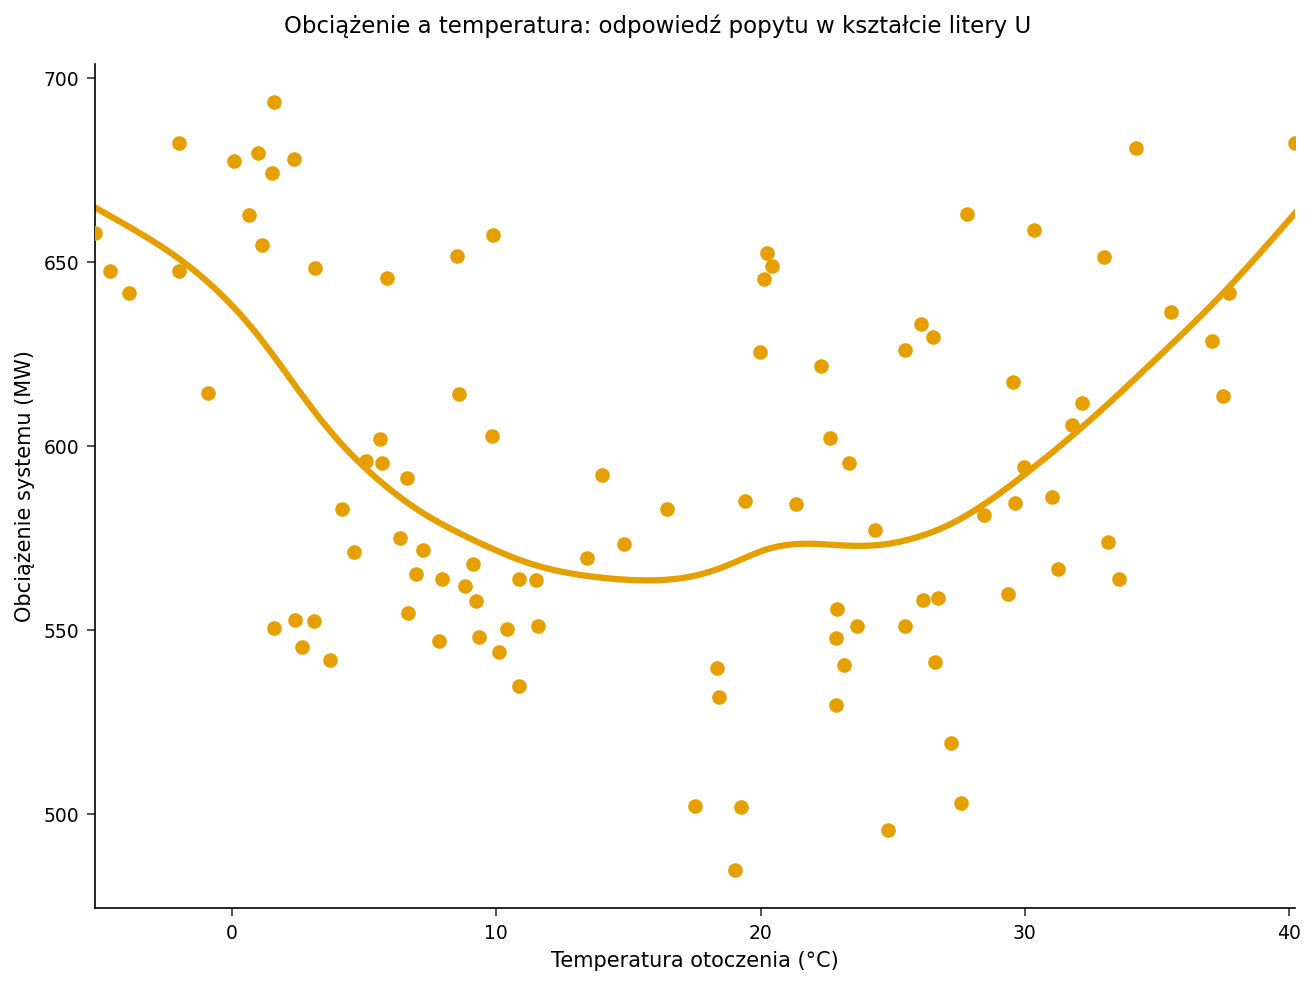

In [4]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DANE=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ETYKIETA="Temperatura otoczenia (°C)";
   YAXIS ETYKIETA="Obciążenie systemu (MW)";
   TYTUŁ "Obciążenie a temperatura: odpowiedź popytu w kształcie litery U";
WYKONAJ;

ODS GRAPHICS OFF;

## Krok 5 — Liczbowe potwierdzenie kształtu litery U

Wykres uwidacznia kształt litery U; podsumowanie w pasmach czyni go liczbowym. Grupujemy obserwacje w zakresy temperatury i raportujemy średnie obciążenie w każdym paśmie. Jeśli odpowiedź popytu jest naprawdę w kształcie litery U, średnie obciążenie powinno być wysokie w paśmie **Zimno**, spadać przez **Chłodno / Komfortowo / Ciepło** i ponownie rosnąć w paśmie **Gorąco** — liczbowy sygnał, który wychwytuje wygładzenie `s(TEMP_C)` GAMPL.

In [5]:
DANE work.banded;
   USTAW work.gridload;
   DŁUGOŚĆ tempband $20;
   JEŚLI      temp_c <  5  WTEDY tempband = "1 Zimno";
   PRZECIWNIE JEŚLI temp_c < 15  WTEDY tempband = "2 Chłodno";
   PRZECIWNIE JEŚLI temp_c < 22  WTEDY tempband = "3 Komfortowo";
   PRZECIWNIE JEŚLI temp_c < 30  WTEDY tempband = "4 Ciepło";
   PRZECIWNIE                      tempband = "5 Gorąco";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=work.banded n mean maxdec=1;
   KLASA tempband;
   ZMIENNA load_mw;
   ETYKIETA tempband="Pasmo temperatury" load_mw="Obciążenie systemu (MW)";
   TYTUŁ "Średnie obciążenie wg pasma temperatury";
WYKONAJ;

                                        Średnie obciążenie wg pasma temperatury                                         

                                                  The MEANS Procedure

                                 Analysis Variable : load_mw Obciążenie systemu (MW)

        Pasmo temperatury          N Obs           Mean
        -----------------------------------------------
        1 Zimno                       21          626.6
        2 Chłodno                     28          579.1
        3 Komfortowo                  12          573.8
        4 Ciepło                      25          573.5
        5 Gorąco                      14          621.6
        -----------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretacja wyników

**Wygładzenia odtwarzają fizykę zjawiska.** Tabela Smoothing Component GAMPL przypisuje członowi temperatury `s(TEMP_C)` efektywne DF 5,53 (*p* < 0,0001), a członowi dobowemu `s(HOUR)` EDF 6,87 (*p* < 0,0001) — oba naprawdę zakrzywione, dokładnie taką strukturę, jaką wbudowaliśmy w dane. Człon wilgotności `s(HUMIDITY)` jest ściągnięty do EDF 1,00 (*p* = 0,07): kara wyprostowuje go do pojedynczego, niemal liniowego stopnia swobody, ponieważ przy tej wielkości próby to wszystko, co wspierają dane. Parametryczne oszacowanie `daytype` wynosi −44,5 MW dla weekendów, odtwarzając przesunięcie poziomu o 40 MW dla dnia roboczego w procesie generującym.

**Efektywne stopnie swobody opowiadają historię pofalowania.** Model zużywa łącznie 15,4 efektywnych stopni swobody i osiąga wynik GCV 239,6 (AIC 831,0, oszacowanie skali 202,7). Ograniczenie `maxdf=` i przypięcie `df=3` w Kroku 3 ledwie porusza dopasowanie (GCV 240,1, EDF 15,47): kara już wcześniej samodzielnie ustaliła wygładzenia temperatury i godziny blisko 5,5 i 7 EDF, więc ręczne ograniczenia są tu niewiążące — znak, że automatyczny wybór był już konserwatywny.

**Wykres i podsumowanie w pasmach są zgodne.** Wykres punktowy z Kroku 4 z nałożonym spenalizowanym splajnem pokazuje obciążenie spadające od skrajnego chłodu do minimum w okolicach 15–20 st. C i ponownie rosnące w upale. Średnie z pasm w Kroku 5 czynią to liczbowym: **Zimno 626,6 MW**, **Chłodno 579,1**, **Komfortowo 573,8**, **Ciepło 573,5**, **Gorąco 621,6** — wysokie na obu końcach, najniższe w komfortowym środku. To U jest dokładnie tym, co pojedynczy liniowy człon `temp_c` uśredniłby.

**Dlaczego GAMPL zamiast regresji liniowej.** Pojedynczy liniowy człon `temp_c` zmieszałby reżimy ogrzewania i chłodzenia w niemal płaskie nachylenie, źle prognozując oba skrajne przypadki — dokładnie te godziny, w których występuje obciążenie sieci i skoki cen. Formuła splajnu addytywnego zachowuje interpretowalność regresji (każdy czynnik wnosi efekt addytywny), pozwalając jednocześnie danym dyktować kształt każdego efektu. Naturalne rozszerzenia dla zakładu energetycznego obejmują dopasowanie `dist=gamma`, jeśli obciążenie jest modelowane multiplikatywnie, dwuwymiarowy `spline(temp_c hour)` do uchwycenia, jak szczyt dobowy przesuwa się z sezonem, oraz przetwarzanie `by` w celu dopasowania osobnych modeli dla każdej podstacji.